In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error


In [3]:
x = np.array([1, 2, 3, 4])
y = np.array([2, 2.8, 3.6, 4.5])


In [5]:
n = len(x)
#================================
#initialize parameters
#================================
w = 0
b = 0
# np.random.seed(42)
# w = np.random.rand()
# b = np.random.rand()
learning_rate = 0.01
epochs = 10000
cost_values = []
print(f"initail w: {w}")
print(f"initail b: {b}")
print(f"learning_rate: {learning_rate}")
print(f"epochs: {epochs}")
print("Training.......................")

initail w: 0
initail b: 0
learning_rate: 0.01
epochs: 10000
Training.......................


In [ ]:
#==========================
#Gradient Descent
#==========================
for i in range(epochs):
    y_hat = w * x + b
    error = y_hat - y

    #Gradients
    d_w = np.mean(error * x)
    d_b = np.mean(error)

    #Update parameters
    w -= learning_rate * d_w
    b -= learning_rate * d_b

    #New line prediction
    y_hat = w * x + b

    #cost 
    cost = np.mean((y_hat - y) ** 2) #MSE
    cost_values.append(cost)

    if (i + 1) % 100 == 0 or i == 0:
        print(f"Epoch {i + 1}:",
              f"cost = {cost}",
              f"w = {w}",
              f"b = {b}")


Epoch 1: cost = 9.4761088125 w = 0.091 b = 0.03225
Epoch 100: cost = 0.07561617368683658 w = 1.0575418455176155 b = 0.48041277301696655
Epoch 200: cost = 0.05623338544242691 w = 1.0260387078113054 b = 0.5736221969706309
Epoch 300: cost = 0.04186894802433068 w = 0.9987646244005063 b = 0.6538114239602598
Epoch 400: cost = 0.031223408807800754 w = 0.9752850537827834 b = 0.7228442248478275
Epoch 500: cost = 0.023333959196083193 w = 0.9550721051704398 b = 0.7822727586702111
Epoch 600: cost = 0.017487058075360058 w = 0.9376713060598337 b = 0.8334332300251728
Epoch 700: cost = 0.013153897411688454 w = 0.9226914129480115 b = 0.8774759425222467
Epoch 800: cost = 0.009942575559392756 w = 0.9097956145300619 b = 0.9153911624708949
Epoch 900: cost = 0.007562652717968797 w = 0.8986939587575554 b = 0.9480313842521912
Epoch 1000: cost = 0.005798882846355757 w = 0.8891368334911053 b = 0.9761304979953049
Epoch 1100: cost = 0.004491746284672753 w = 0.8809093541645698 b = 1.000320290529155
Epoch 1200: cos

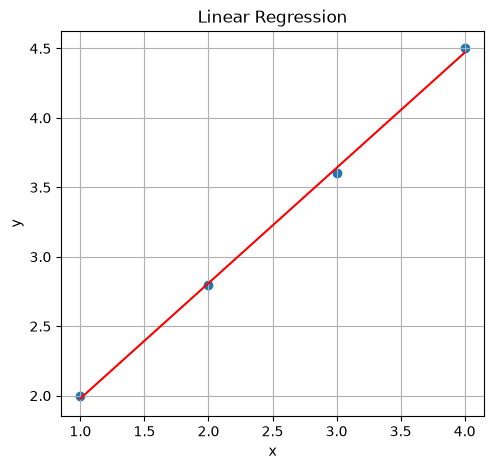

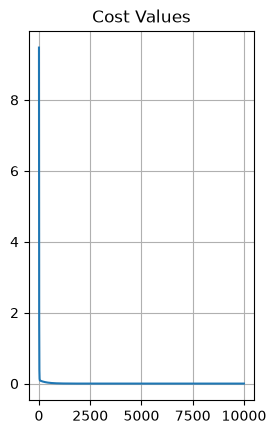

In [10]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, w * x + b, 'r-')
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

plt.subplot(1, 2, 2)
plt.plot(cost_values)
plt.title("Cost Values")
plt.grid()

In [12]:
data = pd.read_csv('Salary_Data.csv')


In [13]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Figure size 300x400 with 0 Axes>

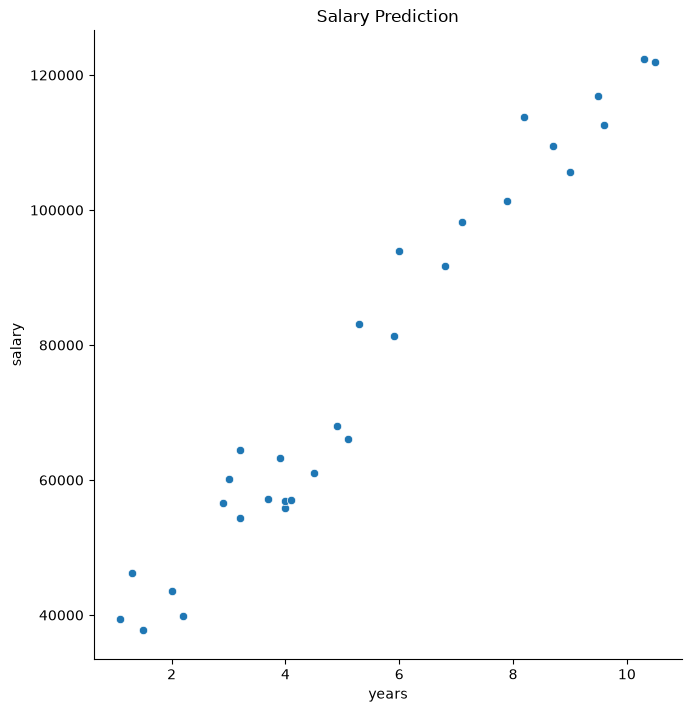

In [16]:
plt.figure(figsize = (3, 4))
sns.pairplot(data, x_vars = ["YearsExperience"], y_vars = ["Salary"], height = 7, kind = 'scatter')
plt.xlabel("years")
plt.ylabel("salary")
plt.title("Salary Prediction")
plt.show()

In [17]:
x = data.iloc[:, :-1]
y = data.iloc[:, 1]

In [21]:
'''
لو حطيت الداتا في التيست ب80 اوتوماتك يخلي الترين ب20
shuffle: بيلغبطلك الداتا
random_state: it is like the seed
'''
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 10)



In [32]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train) #ده بيجيب البراميترز بتاعتك اللي هي الw والb
y_hat_train = lin_reg.predict(x_train) # we use train here just to make sure the training was good


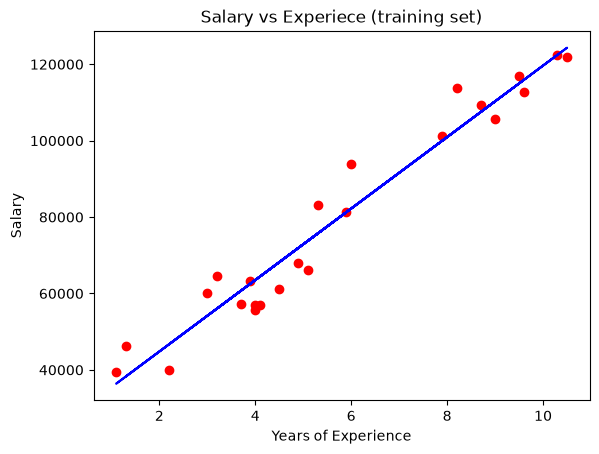

In [34]:
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train, y_hat_train, color = 'blue')
plt.title("Salary vs Experiece (training set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [35]:
y_hat_test = lin_reg.predict(x_test)


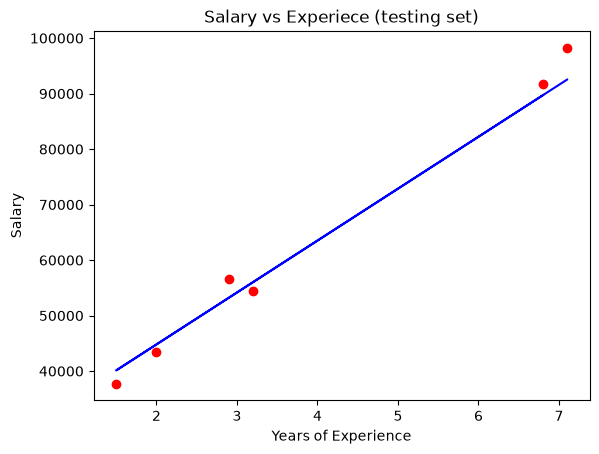

In [36]:
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_test, y_hat_test, color = 'blue')
plt.title("Salary vs Experiece (testing set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [41]:
# Calculate mean square error
mse = mean_squared_error(y_test, y_hat_test)
print(mse)
rmse = root_mean_squared_error(y_test, y_hat_test)
print(rmse)
r2 = r2_score(y_test, y_hat_test)
print(r2)

9785570.138914311
3128.1895944642342
0.9816423482070253


In [45]:
bias = lin_reg.intercept_ #this is the b

In [46]:
w = lin_reg.coef_ #this is the W

In [48]:
new_sal = w * 10 + bias
new_sal

array([119657.72656781])